# Simulating a model with bngsim

bngsim is PyBNF's in-process simulation engine. You do not need to run a fit to use
it: give it a model and it will integrate the dynamics for you. This notebook takes
a small **enzyme-kinetics** model, simulates it forward, and explores how its
behaviour changes with a rate constant — all without leaving the kernel.

In [1]:
import os, tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl; mpl.rcParams['figure.dpi'] = 80

os.environ.setdefault('BNGPATH', os.path.expanduser('~/Simulations/BioNetGen-2.9.3'))
import bngsim
import pybnf_notebook as nb

WORK = Path(tempfile.mkdtemp(prefix='pybnf_bngsim_'))
print('bngsim', bngsim.__version__ if hasattr(bngsim, '__version__') else '(version n/a)')

bngsim 0.9.67


## An enzyme-kinetics model

The textbook Michaelis–Menten scheme: enzyme `E` binds substrate `S` to form a
complex `ES`, which either falls apart again or turns over into product `P`.

```
E + S  <->  ES   (kf, kr)
ES     ->   E + P (kcat)
```

We write it as edition-2 BNGL and let bngsim expand the reaction network.

In [2]:
mm_bngl = '''
begin model
  begin parameters
    kf    0.01     # association   [1/(molecule·s)]
    kr    0.10     # dissociation  [1/s]
    kcat  0.20     # catalysis     [1/s]
    S0    100
    E0    10
  end parameters
  begin molecule types
    E()
    S()
    ES()
    P()
  end molecule types
  begin seed species
    E()   E0
    S()   S0
    ES()  0
    P()   0
  end seed species
  begin observables
    Molecules  S       S()
    Molecules  P       P()
    Molecules  ES      ES()
    Molecules  E_free  E()
  end observables
  begin reaction rules
    bind:   E() + S() -> ES()      kf
    unbind: ES()      -> E() + S() kr
    cat:    ES()      -> E() + P() kcat
  end reaction rules
end model
'''
model_file = WORK / 'michaelis_menten.bngl'
model_file.write_text(mm_bngl)

# Expand rules -> reaction network (.net) once; then load into the bngsim engine.
net = nb.bngl_to_net(model_file, WORK)
model = bngsim.Model.from_net(net)
print('species    :', model.species_names)
print('observables:', model.observable_names)
print('net file   :', Path(net).name)

species    : ['E()', 'S()', 'ES()', 'P()']
observables: ['S', 'P', 'ES', 'E_free']
net file   : michaelis_menten_gen_net.net


## Simulate forward

Build a `Simulator` and `run` it over a time span. The result carries the
observable trajectories; `.dataframe` hands them back as a pandas table.

In [3]:
sim = bngsim.Simulator(model, method='ode')
res = sim.run((0.0, 60.0), n_points=241)     # (t_start, t_end), number of output points
traj = res.dataframe
traj.head()

,time,S,P,ES,E_free
0,0.00,100.000000,0.000000,0.000000,10.000000
1,0.25,89.555970,0.477408,9.966621,0.033379
2,0.50,89.057830,0.975735,9.966435,0.033565
3,0.75,88.559701,1.474052,9.966247,0.033753
4,1.00,88.061583,1.972359,9.966057,0.033943


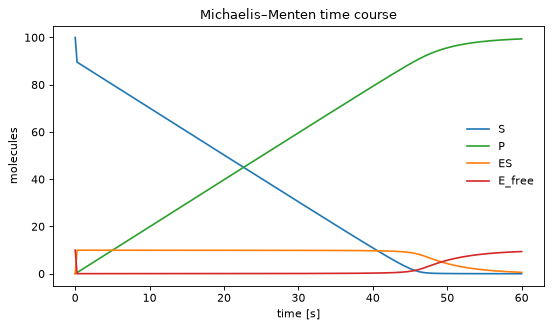

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for col, color in [('S', 'C0'), ('P', 'C2'), ('ES', 'C1'), ('E_free', 'C3')]:
    ax.plot(traj['time'], traj[col], label=col, color=color)
ax.set(xlabel='time [s]', ylabel='molecules', title='Michaelis–Menten time course')
ax.legend(frameon=False); fig.tight_layout()

Substrate `S` is consumed, product `P` accumulates, and the complex `ES` rises to a
quasi-steady plateau while free enzyme `E` is briefly sequestered — the classic MM
picture, straight out of the simulator.

## A parameter sweep

How does the catalytic rate `kcat` shape product formation? We reload a **fresh**
model from the `.net` for each value (so every run starts from the same initial
state), change one parameter, and re-simulate.

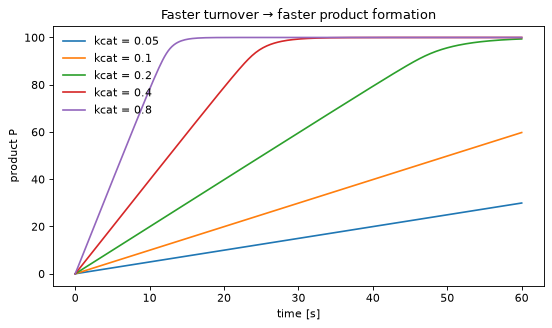

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for kcat in [0.05, 0.1, 0.2, 0.4, 0.8]:
    mk = bngsim.Model.from_net(net)      # fresh model => initial state = seed species
    mk.set_param('kcat', kcat)
    df = bngsim.Simulator(mk, method='ode').run((0.0, 60.0), 241).dataframe
    ax.plot(df['time'], df['P'], label=f'kcat = {kcat}')
ax.set(xlabel='time [s]', ylabel='product P', title='Faster turnover → faster product formation')
ax.legend(frameon=False, title=None); fig.tight_layout()

## Steady state, directly

bngsim can also solve for the steady state without marching through time — useful
for dose–response work. Here we confirm that all substrate ends up as product.

In [6]:
ss = bngsim.Model.from_net(net)
ss_res = bngsim.Simulator(ss, method='ode').run((0.0, 500.0), 2).dataframe.iloc[-1]
print(f"at steady state:  S = {ss_res['S']:.3f}   P = {ss_res['P']:.3f}   (S0 = 100)")

at steady state:  S = -0.000   P = 100.000   (S0 = 100)


That is bngsim as an interactive simulator: load a model, run it, change a
parameter, run it again. When you are ready to *fit* a model to data, the same
engine powers `run_fit` (see `01_quickstart.ipynb`).